In [1]:
from pathlib import Path
import math
import pandas as pd

In [2]:
# base = pd.read_csv (Path(r'aqui la dirección del archivo csv'))
# otra forma con la url
url1 = 'https://gist.githubusercontent.com/ahcamachod/a572cfcc2527046db93101f88011b26e/raw/ffb13f45a79d31223e645611a119397dd127ee3c/alquiler.csv'
#Si no está separado por comas(,) quizá está en punto y comas (;)
pd.read_csv(url1, sep= ';')


,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN
2,Conjunto Comercial/Sala,Santa Fe,0,4,0,150,18200.0,14070.0,3888.5
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
...,...,...,...,...,...,...,...,...,...
25116,Cochera/Estacionamiento,Centro Histórico,0,0,0,755,49000.0,NaN,NaN
25117,Cocineta,Centro Histórico,0,0,0,27,2800.0,1225.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5
25119,Departamento,Lomas de Chapultepec,2,0,0,70,10500.0,2660.0,NaN


# **Almacenamiento de datos**

**Aquí, es fundamental saber algunos códigos para realizar un EDA efectivo (Exploratory Data Analysis)**

In [ ]:
#Almacenar los datos de la inmobiliaria
data = pd.read_csv(url1, sep= ';')

#ver muestra aleatoria de 5 datos
print(data.sample(5))
#dimensión del dataframe
print(data.shape)
#nombre de las columnas, aunque es más completo verlo con .info()
print(data.info())


                          Tipo           Colonia  Habitaciones  Garages  \
2061   Conjunto Comercial/Sala  Centro Histórico             0        0   
1030   Conjunto Comercial/Sala  Centro Histórico             0        0   
3884              Departamento          Santa Fe             4        2   
16027             Tienda/Salón          Santa Fe             0        1   
19353             Departamento              Roma             3        2   

       Suites  Area    Valor  Condominio  Impuesto  
2061        0    28    875.0      1494.5     294.0  
1030        0    35   3500.0      1722.0     339.5  
3884        1   103   9450.0      5600.0     469.0  
16027       0    60   7000.0      4200.0       NaN  
19353       1   170  15750.0      6650.0    1050.0  
(25121, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25121 entries, 0 to 25120
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tipo          25121 n

In [4]:
# Ver una columna: data.Tipo, si se desean ver dos data[['Habitaciones','Valor']]
print (data[['Habitaciones','Valor']])
print (data[data.Tipo=='Departamento']['Habitaciones'])

       Habitaciones    Valor
0                 1   5950.0
1                 2  24500.0
2                 0  18200.0
3                 1   2800.0
4                 1   2800.0
...             ...      ...
25116             0  49000.0
25117             0   2800.0
25118             2   4900.0
25119             2  10500.0
25120             0  22750.0

[25121 rows x 2 columns]
3        1
4        1
7        1
8        1
10       4
        ..
25111    3
25113    3
25114    1
25118    2
25119    2
Name: Habitaciones, Length: 14764, dtype: int64


In [5]:
#promedio del valor por tipo de arriendos con dos decimales filtrar la columna valor con .Valor o ['Valor']
round(data.groupby('Tipo')['Valor'].mean(),2)
'''Lo anterior muy bien, pero, ¿Es lo mejor en formato de series?,
es mejor verlo en formato DataFrame con el siguiente código de forma descendente'''
print (round(data.groupby('Tipo')[['Valor']].mean().sort_values('Valor')[::-1]))
#El más barato? Respuesta: Cocineta
#Guardamos este último DataFrame
df_tipo_precio = round(data.groupby('Tipo')[['Valor']].mean().sort_values('Valor')[::-1],2)

                               Valor
Tipo                                
Industria                   420000.0
Edificio Completo           409418.0
Galpón/Depósito/Almacén     299984.0
Terreno Estándar            135364.0
Loteo/Condominio             92167.0
Hotel                        87500.0
Conjunto Comercial/Sala      57675.0
Tienda/Salón                 56264.0
Casa Comercial               54736.0
Casa de Condominio           51429.0
Rancho                       38014.0
Tienda en Centro Comercial   32557.0
Casa                         31453.0
Departamento                 18683.0
Departamento en Hotel        16285.0
Loft                          9925.0
Estudio                       8400.0
Cochera/Estacionamiento       6995.0
Casa de Vecindad              5962.0
Posada/Chalé                  5180.0
Cocineta                      4426.0


<Axes: ylabel='Tipo'>

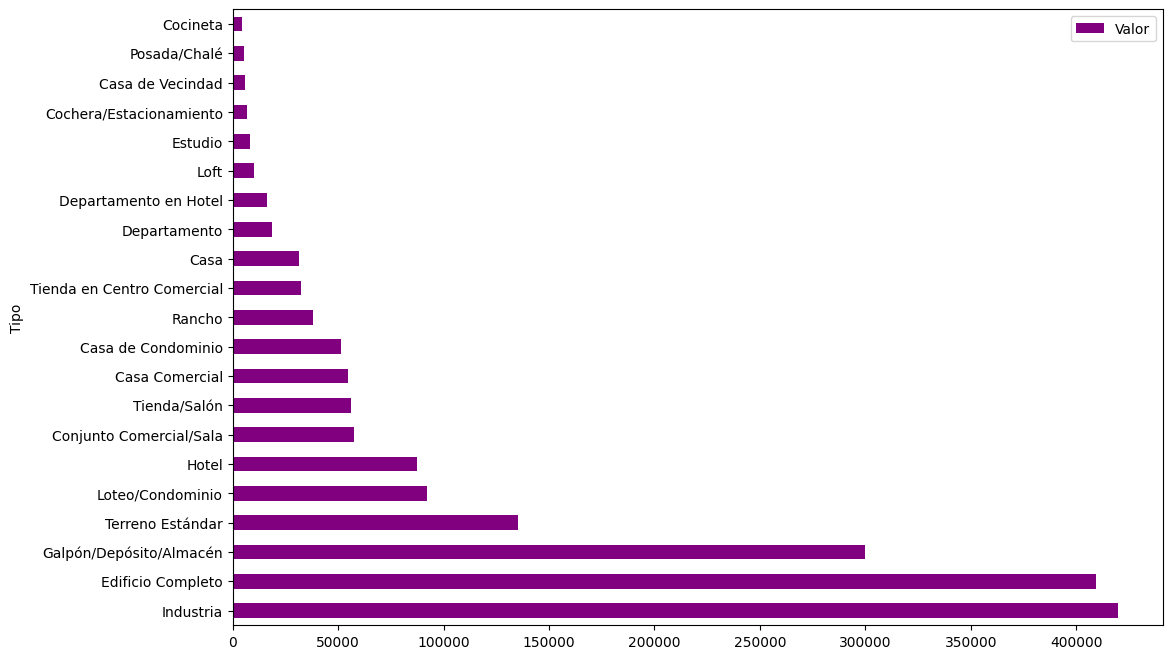

In [6]:
df_tipo_precio.plot(kind='barh', figsize=(12,8), color= 'purple') #(12x8) es el tamaño de la gráfica

In [7]:
df = pd.DataFrame({
   'Animal': ['Perro', 'Gato', 'Elefante', 'Perro', 'Gato', 'Elefante'],
   'Color': ['Negro', 'Blanco', 'Gris', 'Marrón', 'Negro', 'Marrón'],
   'Cantidad': [2, 3, 1, 4, 2, 2]
})
print (df)
print (df.groupby('Animal').sum())

#Agrupar por dos columnas y que sume las cantidades
df.groupby(['Animal','Color'])[['Cantidad']].sum()

     Animal   Color  Cantidad
0     Perro   Negro         2
1      Gato  Blanco         3
2  Elefante    Gris         1
3     Perro  Marrón         4
4      Gato   Negro         2
5  Elefante  Marrón         2
                Color  Cantidad
Animal                         
Elefante   GrisMarrón         3
Gato      BlancoNegro         5
Perro     NegroMarrón         6


Cantidad
Animal   Color           
Elefante Gris           1
         Marrón         2
Gato     Blanco         3
         Negro          2
Perro    Marrón         4
         Negro          2

In [8]:
#Ver valores únicos (distintos) de una columna
data.Tipo.unique()

array(['Cocineta', 'Casa', 'Conjunto Comercial/Sala', 'Departamento',
       'Casa de Condominio', 'Edificio Completo', 'Departamento en Hotel',
       'Tienda/Salón', 'Casa Comercial', 'Casa de Vecindad',
       'Terreno Estándar', 'Cochera/Estacionamiento', 'Loft',
       'Galpón/Depósito/Almacén', 'Tienda en Centro Comercial', 'Rancho',
       'Posada/Chalé', 'Estudio', 'Hotel', 'Loteo/Condominio',
       'Industria'], dtype=object)

In [9]:
#Saber todos los inmuebles comerciales
#Creamos una lista de inmuebles que a NUESTRO CRITERIO consideremos comerciales.. para luego buscar la negación, es decir, los RESIDENCIALES
#Esto es para hacer un "filtro" express de una lista de lo que queremos en una base de datos tipo DataFrame
inmuebles_comerciales = [
    'Conjunto Comercial/Sala',
    'Edificio Completo',
    'Tienda/Salón',
    'Casa Comercial',
    'Cochera/Estacionamiento',
    'Galpón/Depósito/Almacén',
    'Tienda en Centro Comercial',
    'Industria',
    'Terreno Estándar',
    'Hotel',
    'Loteo/Condominio'
]

display(data.query('@inmuebles_comerciales not in Tipo'))
#guardamos la data filtrada de residenciales
df_residenciales = data.query('@inmuebles_comerciales not in Tipo')

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
5,Casa de Condominio,Santa Fe,5,4,5,750,77000.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
25114,Departamento,Narvarte,1,0,0,28,3500.0,1260.0,87.5
25115,Casa de Condominio,Santa Fe,5,3,4,450,52500.0,5988.5,8162.0
25117,Cocineta,Centro Histórico,0,0,0,27,2800.0,1225.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5


<Axes: ylabel='Density'>

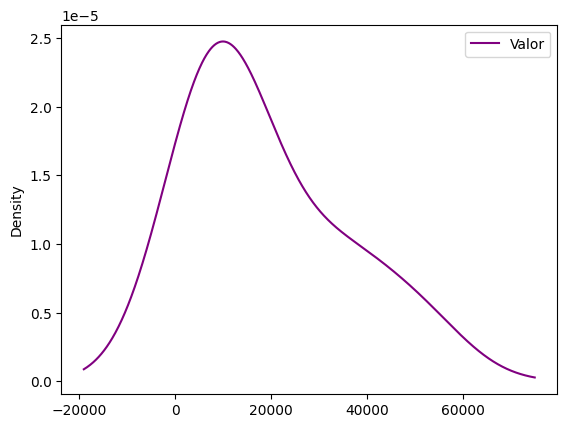

In [ ]:
#Visualizar los datos residenciales
#primero agrupar los datos, muy importante
df_residenciales_precios = df_residenciales.groupby('Tipo')[['Valor']].mean().sort_values('Valor')
df_residenciales_precios.plot(kind='kde', color= 'purple')

In [11]:
#Contar tipo de departamentos y ver sus porcentajes (en decimales) y que sea en DataFrame y no Series
display(df_residenciales['Tipo'].value_counts(normalize=True).to_frame())
#Ver solamente departamentos se usan distintas comillas para filtrar dentro de un filtro query, display es para que se siga viendo bien el DataFrame
display(df_residenciales.query('Tipo=="Departamento"')) #LO MISMO QUE ABAJO
display(df_residenciales[df_residenciales['Tipo']=='Departamento']) #LO MISMO QUE ARRIBA
df_departamentos = df_residenciales.query('Tipo=="Departamento"')

,proportion
Tipo,
Departamento,0.852967
Cocineta,0.041943
Casa de Condominio,0.035242
Casa,0.031487
Departamento en Hotel,0.026287
Casa de Vecindad,0.009128
Loft,0.002195
Rancho,0.000462
Estudio,0.000231


,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
7,Departamento,Centro Histórico,1,0,0,36,4200.0,NaN,NaN
8,Departamento,Condesa,1,0,1,40,7000.0,1963.5,175.0
10,Departamento,Condesa,4,3,1,243,45500.0,7000.0,2810.5
...,...,...,...,...,...,...,...,...,...
25111,Departamento,Lomas de Chapultepec,3,0,1,80,10500.0,3535.0,871.5
25113,Departamento,Coyoacán,3,1,2,150,52500.0,4900.0,2100.0
25114,Departamento,Narvarte,1,0,0,28,3500.0,1260.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5


,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN
7,Departamento,Centro Histórico,1,0,0,36,4200.0,NaN,NaN
8,Departamento,Condesa,1,0,1,40,7000.0,1963.5,175.0
10,Departamento,Condesa,4,3,1,243,45500.0,7000.0,2810.5
...,...,...,...,...,...,...,...,...,...
25111,Departamento,Lomas de Chapultepec,3,0,1,80,10500.0,3535.0,871.5
25113,Departamento,Coyoacán,3,1,2,150,52500.0,4900.0,2100.0
25114,Departamento,Narvarte,1,0,0,28,3500.0,1260.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5


<Axes: xlabel='Tipo de arriendo', ylabel='Proporción'>

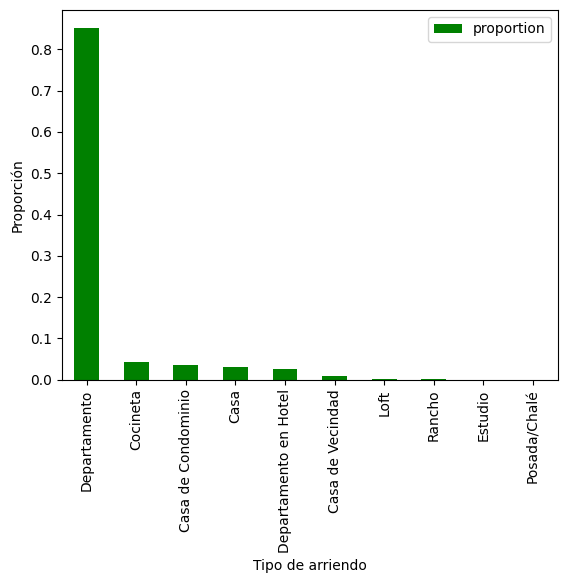

In [12]:
#Graficar lo anterior
porcentaje_tipos = df_residenciales.Tipo.value_counts(normalize=True).to_frame()
porcentaje_tipos.plot(kind='bar', color = 'green', xlabel = 'Tipo de arriendo', ylabel = 'Proporción')

In [13]:
#Renombrar columnas
#Ver nombre de las columnas muy importante porque a veces rename no funciona si no se sabe el nombre exacto
display (porcentaje_tipos.columns)
display (porcentaje_tipos.rename(columns = {'proportion': 'Proporción'}))

Index(['proportion'], dtype='object')

,Proporción
Tipo,
Departamento,0.852967
Cocineta,0.041943
Casa de Condominio,0.035242
Casa,0.031487
Departamento en Hotel,0.026287
Casa de Vecindad,0.009128
Loft,0.002195
Rancho,0.000462
Estudio,0.000231


### **Demanda del equipo de Machine Learning**
**1. Calcular el promedio de habitaciones por departamento.**

**2. Verificar cuántas colonias únicas existen en nuestra base de datos.**

**3. Analizar qué colonias tienen el promedio de alquiler más alto.**

**4. Crear un gráfico de barras horizontales que muestre las 5 colonias con los promedios de alquiler más altos.**

2.5041994039555675
2.5041994039555675
88


,Valor
Colonia,
San Juan Xalpa,420926.739130
Nativitas,244684.395062
La Merced,213292.770833
Santa Marta Acatitla,166048.105263
Villa de Cortés,135737.411765


Axes(0.125,0.11;0.775x0.77)


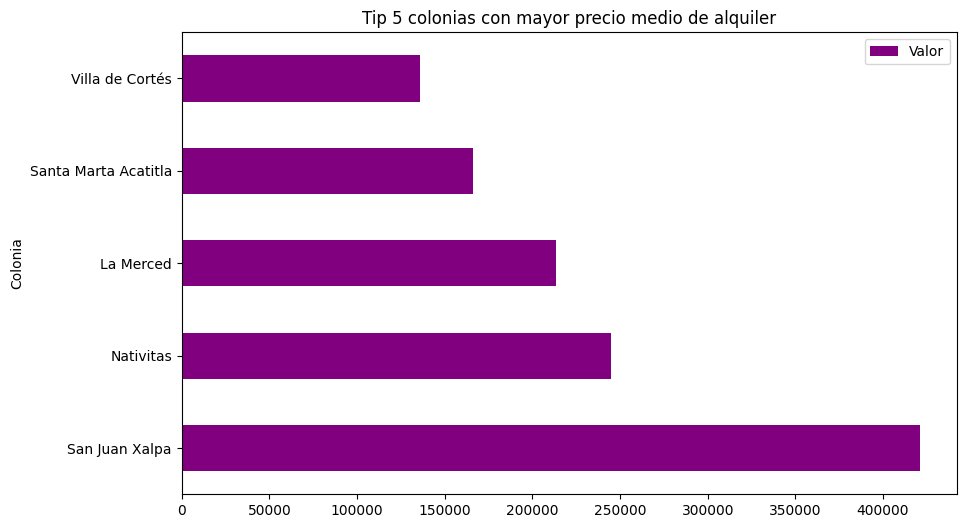

In [14]:
# 1.
print (data[data['Tipo']=='Departamento']['Habitaciones'].mean())
print (data.query ('Tipo=="Departamento"')['Habitaciones'].mean())

# 2.
print (data.Colonia.nunique())

# 3.
display (data.groupby('Colonia')[['Valor']].mean().sort_values('Valor', ascending=False).head(5))

# 4.
top_price_colonia = data.groupby('Colonia')[['Valor']].mean().sort_values('Valor')[::-1].head(5)
print (top_price_colonia.plot(
    kind='barh',
    figsize= (10,6),
    title= 'Tip 5 colonias con mayor precio medio de alquiler',
    color = 'purple'))

### **Tratanto con datos nulos**

In [15]:
data.columns
#Si quieremos saber qué columnas tienen datos nulos usamos lo siguiente: .isnull() y además .sum(), porque si sumamos ceros no debería haber suma...
display(data.isnull().sum().to_frame()) #Determinamos que las variables Valor, Condominio e Impuesto contienen datos nulos, es decir, no existen valores en algunas celdas del dataframe

# Eliminar filas con cualquier nulo: df.dropna(inplace=True)

# O reemplazar nulos con un valor df.fillna(0, inplace=True) o con algún valor promedio, mediana, etc, Inplace es para reemplazar en el mismo DF en vez de asignar uno nuevo
df = data.fillna(0)
#confirmamos...
display(df.isnull().sum().to_frame())

#Interpolar se usa .interpolate() de forma lineal, rellenar con el anterior es .ffill y posterior data.bfill()
#bfill significa forward fill y bfill es backward fill

,0
Tipo,0
Colonia,0
Habitaciones,0
Garages,0
Suites,0
Area,0
Valor,14
Condominio,2626
Impuesto,7084


,0
Tipo,0
Colonia,0
Habitaciones,0
Garages,0
Suites,0
Area,0
Valor,0
Condominio,0
Impuesto,0


### **IMPORTANTE**

- **En el DataFrame muchas veces uno quiere eliminar espacios al principio y final de los strings, como por ejemplo:**
    1. Elementos (celdas) que están como: 'Maria ', ' Patricio', etc.. u otras variables como por ej. sucursales: 'Constitucion ', 'Valparaiso  '.

- **Para lo anterior se debe aplicar:** <span style="color:orange; font-weight:bold"> data.applymap(lambda x: x.strip() if isinstance(x, str) else x)</span>

### Registros sin sentido...

- Departamentos con un valor de alquiler igual a 0.

- Departamentos con un valor de condominio igual a 0.

- Estos registros son inconsistentes, por lo tanto, debemos eliminarlos de nuestra base de datos.

In [16]:
display(df.query ('Tipo=="Departamento" & (Valor==0 | Condominio==0)')) # el simbolo ' | ' significa or (o)

#Luego hacemos un filtro de esta base en base al índice para luego agregar los índices a la data con ceros y eliminar sus filas
remover_ceros = df.query ('Tipo=="Departamento" & (Valor==0 | Condominio==0)').index

#Aplicamos a la base "df" original usando inplace=True
df.drop(remover_ceros, inplace=True)
print(df)

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
7,Departamento,Centro Histórico,1,0,0,36,4200.0,0.0,0.0
49,Departamento,Santa Fe,2,1,1,70,0.0,3395.0,238.0
74,Departamento,Ciudad de los Deportes,2,0,0,80,3500.0,0.0,0.0
116,Departamento,El Rosedal,2,1,0,50,3850.0,0.0,0.0
136,Departamento,Santa Fe,1,1,1,65,8225.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
24721,Departamento,Doctores,2,0,0,43,3150.0,0.0,56.0
24736,Departamento,Condesa,1,0,0,30,9100.0,0.0,0.0
24866,Departamento,Condesa,3,0,0,130,16100.0,0.0,0.0
24892,Departamento,Loma Bonita,1,0,0,40,1925.0,0.0,0.0


                          Tipo               Colonia  Habitaciones  Garages  \
0                     Cocineta               Condesa             1        0   
1                         Casa               Polanco             2        0   
2      Conjunto Comercial/Sala              Santa Fe             0        4   
3                 Departamento      Centro Histórico             1        0   
4                 Departamento             Del Valle             1        0   
...                        ...                   ...           ...      ...   
25116  Cochera/Estacionamiento      Centro Histórico             0        0   
25117                 Cocineta      Centro Histórico             0        0   
25118             Departamento               Mixcoac             2        1   
25119             Departamento  Lomas de Chapultepec             2        0   
25120  Conjunto Comercial/Sala      Centro Histórico             0        0   

       Suites  Area    Valor  Condominio  Impuesto 

In [17]:
#Verificar si se eliminaron las filas con ceros...
display(df.query ('Tipo=="Departamento" & (Valor==0 | Condominio==0)'))
df_departamentos = df.query ('Tipo=="Departamento"').copy()

#Si todos son departamentos... mejor eliminemos esa columna que dicen todos "Departamento", eliminar columna con Axis=1
df_departamentos.drop('Tipo', axis=1, inplace=True)
display(df_departamentos)

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto


,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
3,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
4,Del Valle,1,0,0,48,2800.0,805.0,0.0
8,Condesa,1,0,1,40,7000.0,1963.5,175.0
10,Condesa,4,3,1,243,45500.0,7000.0,2810.5
13,Santa Fe,2,1,1,67,5950.0,2061.5,514.5
...,...,...,...,...,...,...,...,...
25111,Lomas de Chapultepec,3,0,1,80,10500.0,3535.0,871.5
25113,Coyoacán,3,1,2,150,52500.0,4900.0,2100.0
25114,Narvarte,1,0,0,28,3500.0,1260.0,87.5
25118,Mixcoac,2,1,0,48,4900.0,1781.5,129.5


### Evaluación de propiedades

- Apartamentos que tienen 1 dormitorio y un alquiler menor a MXN 4200.

In [18]:
df_departamentos.query ('Habitaciones==1 & Valor < 4200').sort_values('Valor')[::-1]

,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
23513,Condesa,1,0,0,38,4025.0,2730.0,0.0
2750,La Condesa,1,0,1,40,4025.0,1820.0,0.0
10874,Centro Histórico,1,0,0,33,4025.0,1295.0,70.0
12430,La Condesa,1,0,0,47,4025.0,1750.0,87.5
614,Centro Histórico,1,0,1,38,4025.0,1400.0,87.5
...,...,...,...,...,...,...,...,...
4211,Ciudad de los Deportes,1,0,0,47,1750.0,35.0,0.0
2820,Ciudad de los Deportes,1,1,0,48,1575.0,962.5,0.0
21456,Santa Marta Acatitla,1,1,0,40,1400.0,770.0,0.0
1261,Nativitas,1,0,0,35,1400.0,455.0,0.0


- Apartamentos que tienen al menos 2 dormitorios, un alquiler menor a MXN 10500 y una superficie mayor a 70 m².

In [19]:
df_departamentos.query ('Habitaciones >= 2 & Valor < 10500 & Area > 70')

,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
14,Narvarte,2,1,0,110,6650.0,2450.0,483.0
16,Narvarte,2,1,0,78,7000.0,2450.0,0.0
21,Roma,2,1,0,76,8750.0,2590.0,0.0
33,Santa Fe,3,1,1,72,8225.0,2100.0,245.0
58,Santa Fe,3,2,1,104,9100.0,4774.0,1421.0
...,...,...,...,...,...,...,...,...
25028,Del Valle,2,0,1,90,7700.0,1890.0,483.0
25062,Santa Fe,2,1,1,72,5950.0,3045.0,560.0
25063,Narvarte,3,1,0,75,6650.0,3010.0,493.5
25105,Santa Fe,2,1,1,85,7875.0,5463.5,689.5


# Guardando los datos

In [20]:
df_departamentos.to_csv('inmuebles_dpto_ML.csv',index=False) #Sin indice porque se creará una nueva columna de los indices... y son sep=';' por si no quiero separar por comas

pd.read_csv('inmuebles_dpto_ML.csv') # Si se desea visualizar...

,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
0,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0
1,Del Valle,1,0,0,48,2800.0,805.0,0.0
2,Condesa,1,0,1,40,7000.0,1963.5,175.0
3,Condesa,4,3,1,243,45500.0,7000.0,2810.5
4,Santa Fe,2,1,1,67,5950.0,2061.5,514.5
...,...,...,...,...,...,...,...,...
14259,Lomas de Chapultepec,3,0,1,80,10500.0,3535.0,871.5
14260,Coyoacán,3,1,2,150,52500.0,4900.0,2100.0
14261,Narvarte,1,0,0,28,3500.0,1260.0,87.5
14262,Mixcoac,2,1,0,48,4900.0,1781.5,129.5


### **Práctica: DB de alumnos**

1. *Verifica si la base de datos contiene datos nulos y, en caso de tenerlos, realiza el tratamiento de estos datos nulos de la manera que consideres más coherente con la situación.*

2. *Los estudiantes "Alicia" y "Carlos" ya no forman parte del grupo. Por lo tanto, elimínalos de la base de datos.*

3. *Aplica un filtro que seleccione solo a los estudiantes que fueron aprobados.*

4. *Guarda el DataFrame que contiene solo a los estudiantes aprobados en un archivo CSV llamado "alumnos_aprobados.csv".*

In [21]:
url2 = 'https://gist.githubusercontent.com/ahcamachod/807a2c1cf6c19108b2b701ea1791ab45/raw/fb84f8b2d8917a89de26679eccdbc8f9c1d2e933/alumnos.csv'
alumnos = pd.read_csv (url2)
alumnos

,Nombre,Edad,Nota,Aprobado
0,Alberto,20,7.5,True
1,Ana,18,NaN,False
2,Camila,27,2.5,False
3,David,18,5.0,False
4,Brian,21,10.0,True
5,Bruna,23,NaN,False
6,Daniela,21,7.0,True
7,Carlos,19,6.0,False
8,Alicia,35,5.6,False
9,Victor,28,NaN,False


#### Datos nulos en alumnos
- Eliminamos los datos nulos, dado que no se les debe agregar una nota que un alumno no obtuvo.

In [22]:
display (alumnos.isnull().sum())
alumnos.fillna(0, inplace=True)
display(alumnos)

Nombre      0
Edad        0
Nota        6
Aprobado    0
dtype: int64

,Nombre,Edad,Nota,Aprobado
0,Alberto,20,7.5,True
1,Ana,18,0.0,False
2,Camila,27,2.5,False
3,David,18,5.0,False
4,Brian,21,10.0,True
5,Bruna,23,0.0,False
6,Daniela,21,7.0,True
7,Carlos,19,6.0,False
8,Alicia,35,5.6,False
9,Victor,28,0.0,False


#### Eliminación de alumnos

- Los estudiantes "Alicia" y "Carlos" ya no forman parte del grupo. Por lo tanto, elimínalos de la base de datos.

In [23]:
alumnos.drop(alumnos.query ('Nombre == "Alicia" | Nombre == "Carlos"').index, inplace=True)
alumnos

,Nombre,Edad,Nota,Aprobado
0,Alberto,20,7.5,True
1,Ana,18,0.0,False
2,Camila,27,2.5,False
3,David,18,5.0,False
4,Brian,21,10.0,True
5,Bruna,23,0.0,False
6,Daniela,21,7.0,True
9,Victor,28,0.0,False
10,Danilo,21,0.0,False
11,Ignacio,24,4.5,False


#### Aprobados

- Aplica un filtro que seleccione solo a los estudiantes que fueron aprobados.

In [24]:
display (alumnos[alumnos['Nota']>=7])

alumnos_aprobados = alumnos[alumnos['Nota']>=7].copy()
alumnos_aprobados ['Aprobado'].replace ('Verdadero', True , inplace= True)
alumnos_aprobados.to_csv ('Alumnos_aprobados.csv', sep= ';', index= False)

,Nombre,Edad,Nota,Aprobado
0,Alberto,20,7.5,True
4,Brian,21,10.0,True
6,Daniela,21,7.0,True
12,Stephany,26,10.0,True
13,Miriam,25,9.0,True
15,Milena,29,7.0,True
17,Nadia,34,8.0,Verdadero


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6040\1595933242.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  alumnos_aprobados ['Aprobado'].replace ('Verdadero', True , inplace= True)


#### **Correción de notas**

- Al revisar las calificaciones de los estudiantes aprobados, notamos que algunas calificaciones eran incorrectas. Las estudiantes que obtuvieron una calificación de 7.0, en realidad tenían un punto extra que no se contabilizó. Por lo tanto, reemplaza las calificaciones de 7.0 en la base de datos por 8.0. Consejo: busca el método replace.

In [25]:
alumnos_aprobados['Nota'].replace(7, 8, inplace=True)
display (alumnos_aprobados)
alumnos_aprobados.to_csv ('Alumnos_aprobados.csv', sep= ';', index= False)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6040\2593697166.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  alumnos_aprobados['Nota'].replace(7, 8, inplace=True)


,Nombre,Edad,Nota,Aprobado
0,Alberto,20,7.5,True
4,Brian,21,10.0,True
6,Daniela,21,8.0,True
12,Stephany,26,10.0,True
13,Miriam,25,9.0,True
15,Milena,29,8.0,True
17,Nadia,34,8.0,True


# Crear y modificar columnas

### **Crear columnas**

#### valor_mensual: 

- Esta columna debe contener los gastos mensuales de cada propiedad, incluyendo el alquiler y el condominio.

In [26]:
datos = pd.read_csv (url1, sep= ';') #Cargamos la base
datos.tail()

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto
25116,Cochera/Estacionamiento,Centro Histórico,0,0,0,755,49000.0,NaN,NaN
25117,Cocineta,Centro Histórico,0,0,0,27,2800.0,1225.0,87.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5
25119,Departamento,Lomas de Chapultepec,2,0,0,70,10500.0,2660.0,NaN
25120,Conjunto Comercial/Sala,Centro Histórico,0,0,0,250,22750.0,14721.0,3881.5


In [27]:
datos['Valor_mensual'] = datos.Valor + datos.Impuesto
datos.tail()

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto,Valor_mensual
25116,Cochera/Estacionamiento,Centro Histórico,0,0,0,755,49000.0,NaN,NaN,NaN
25117,Cocineta,Centro Histórico,0,0,0,27,2800.0,1225.0,87.5,2887.5
25118,Departamento,Mixcoac,2,1,0,48,4900.0,1781.5,129.5,5029.5
25119,Departamento,Lomas de Chapultepec,2,0,0,70,10500.0,2660.0,NaN,NaN
25120,Conjunto Comercial/Sala,Centro Histórico,0,0,0,250,22750.0,14721.0,3881.5,26631.5


#### valor_anual: 

- Esta columna debe contener los gastos anuales por propiedad, es decir, el Impuesto más 12 meses de alquiler y condominio.

In [28]:
datos['Valor_anual'] = datos.Valor*12 + datos.Impuesto*12
datos.head()

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto,Valor_mensual,Valor_anual
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0,6160.0,73920.0
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN,NaN,NaN
2,Conjunto Comercial/Sala,Santa Fe,0,4,0,150,18200.0,14070.0,3888.5,22088.5,265062.0
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0,2870.0,34440.0
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN,NaN,NaN


#### Descripción:

- Descripcion: Esta columna debe contener un resumen de la información clave de las propiedades que se mostrarán en el sitio web: tipo de propiedad, barrio, cantidad de habitaciones y plazas de estacionamiento.

In [29]:
import random
datos['Descripcion'] = datos.Tipo + ' en el barrio ' + datos.Colonia + ' con ' + datos.Habitaciones.astype(str) + ' habitaciones y ' + datos.Garages.astype(str) + ' estacionamientos'
for i in range (1,6):
    print (i, datos['Descripcion'].loc[random.randint(1,len(datos.Descripcion))])

1 Departamento en el barrio Coyoacán con 2 habitaciones y 1 estacionamientos
2 Departamento en el barrio Condesa con 1 habitaciones y 0 estacionamientos
3 Departamento en el barrio Condesa con 3 habitaciones y 1 estacionamientos
4 Departamento en el barrio Polanco con 1 habitaciones y 0 estacionamientos
5 Conjunto Comercial/Sala en el barrio Narvarte con 0 habitaciones y 0 estacionamientos


#### Suite:

- Tiene_suite: Esta debe ser una columna que indique únicamente si la propiedad tiene o no suites, sin importar la cantidad.

In [30]:
datos['Tiene_Suite'] = datos['Suites'].apply (lambda x: 'SI' if x > 0 else 'NO')
datos.head()

,Tipo,Colonia,Habitaciones,Garages,Suites,Area,Valor,Condominio,Impuesto,Valor_mensual,Valor_anual,Descripcion,Tiene_Suite
0,Cocineta,Condesa,1,0,0,40,5950.0,1750.0,210.0,6160.0,73920.0,Cocineta en el barrio Condesa con 1 habitacion...,NO
1,Casa,Polanco,2,0,1,100,24500.0,NaN,NaN,NaN,NaN,Casa en el barrio Polanco con 2 habitaciones y...,SI
2,Conjunto Comercial/Sala,Santa Fe,0,4,0,150,18200.0,14070.0,3888.5,22088.5,265062.0,Conjunto Comercial/Sala en el barrio Santa Fe ...,NO
3,Departamento,Centro Histórico,1,0,0,15,2800.0,1365.0,70.0,2870.0,34440.0,Departamento en el barrio Centro Histórico con...,NO
4,Departamento,Del Valle,1,0,0,48,2800.0,805.0,NaN,NaN,NaN,Departamento en el barrio Del Valle con 1 habi...,NO


- Investigar sobre esto:

import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt

# Práctica general:

### Ejercicio 1

- Los estudiantes participaron en una actividad extracurricular y ganaron puntos extras. Estos puntos extras corresponden al 40% de su nota actual. Por lo tanto, crea una columna llamada "Puntos_extras" que contenga los puntos extras de cada estudiante, es decir, el 40% de su nota actual.

### Ejercicio 2

- Crea otra columna llamada "Notas_finales" que contenga las notas de cada estudiante sumadas con los puntos extras.

### Ejercicio 3

- Dado que hubo una puntuación extra, algunos estudiantes que no habían sido aprobados antes pueden haber sido aprobados ahora. En función de esto, crea una columna llamada "Aprobado_final" con los siguientes valores:

### Ejercicio 4

- True: si el estudiante está aprobado (la nota final debe ser mayor o igual a 7.0).
False: si el estudiante está reprobado (la nota final debe ser menor que 7.0).
Realiza una selección y verifica qué estudiantes no habían sido aprobados anteriormente, pero ahora fueron aprobados después de sumar los puntos extras.